# 🤖 03 – Modeling: Isolation Forest & Random Forest
**Proyek:** AI-Based Pharmaceutical Data Selection & Monitoring  
**Tim:** PJK-GM016 | Pijak × IBM SkillsBuild  
**Minggu:** 3 – Pengembangan & Evaluasi Model AI

---
### Alur Notebook
| # | Langkah |
|---|---------|
| 1 | Import & Load Data |
| 2 | Persiapan Fitur & Label |
| 3 | Feature Encoding |
| 4 | Split & Scaling |
| 5 | Isolation Forest (Deteksi Anomali) |
| 6 | Random Forest (Klasifikasi) |
| 7 | Hyperparameter Tuning |
| 8 | Evaluasi & Visualisasi |
| 9 | Feature Importance |
| 10 | Simpan Model |


## ⚙️ 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_recall_curve, average_precision_score)
import joblib

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
COLORS = {"normal": "#2ecc71", "defect": "#e74c3c"}
print("✅ Semua library berhasil diimport")
print(f"   scikit-learn: {__import__('sklearn').__version__}")

✅ Semua library berhasil diimport
   scikit-learn: 1.8.0


## 📂 2. Load Data & Persiapan Fitur

In [2]:
df = pd.read_csv("rekap_produksi_clean.csv", low_memory=False)
print(f"Data dimuat: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Defect rate: {df['Defect_Overall'].mean()*100:.2f}%")

# ── Fitur numerik utama untuk model ──────────────────────────────
FEATURE_COLS = [
    'GB_Yield_Total',
    'GK_Yield_Total',
    'Rasio_GK_GB',
    'GB_Kadar_Air_Mean',
    'Cetak_Yield_Kg',
    'Cetak_Pct_Teoritis',
    'Kemas_Pct_Teoritis',
    'Total_Waste_Kg',
    'Cetak_Durasi_Hari',
    'Kemas_Durasi_Hari',
    'Bulan_Produksi',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET = 'Defect_Overall'

print(f"\nFitur yang digunakan ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    pct_valid = df[f].notna().mean()*100
    print(f"  {f:30s} {pct_valid:.1f}% valid")

Data dimuat: 662 baris × 65 kolom
Defect rate: 7.25%

Fitur yang digunakan (11):
  GB_Yield_Total                 100.0% valid
  GK_Yield_Total                 100.0% valid
  Rasio_GK_GB                    100.0% valid
  GB_Kadar_Air_Mean              98.9% valid
  Cetak_Yield_Kg                 100.0% valid
  Cetak_Pct_Teoritis             99.7% valid
  Kemas_Pct_Teoritis             99.7% valid
  Total_Waste_Kg                 100.0% valid
  Cetak_Durasi_Hari              97.1% valid
  Kemas_Durasi_Hari              94.9% valid
  Bulan_Produksi                 97.1% valid


## 🏷️ 3. Encode Fitur Kategorikal (Mesin)

In [3]:
cat_cols = ['GB_Mesin_L1', 'Cetak_Mesin', 'Kemas_Mesin']
le = LabelEncoder()

for col in cat_cols:
    if col in df.columns:
        df[f'{col}_enc'] = le.fit_transform(df[col].fillna('UNKNOWN').astype(str))
        FEATURE_COLS.append(f'{col}_enc')

print(f"Total fitur setelah encoding: {len(FEATURE_COLS)}")
print("Fitur:", FEATURE_COLS)

Total fitur setelah encoding: 14
Fitur: ['GB_Yield_Total', 'GK_Yield_Total', 'Rasio_GK_GB', 'GB_Kadar_Air_Mean', 'Cetak_Yield_Kg', 'Cetak_Pct_Teoritis', 'Kemas_Pct_Teoritis', 'Total_Waste_Kg', 'Cetak_Durasi_Hari', 'Kemas_Durasi_Hari', 'Bulan_Produksi', 'GB_Mesin_L1_enc', 'Cetak_Mesin_enc', 'Kemas_Mesin_enc']


## ✂️ 4. Split Data & Scaling

In [4]:
# Siapkan X dan y, hapus baris dengan NaN di fitur
df_model = df[FEATURE_COLS + [TARGET]].dropna()
X = df_model[FEATURE_COLS]
y = df_model[TARGET]

print(f"Dataset setelah dropna : {len(df_model)} baris")
print(f"Distribusi label       : Normal={y.value_counts()[0]}, Defect={y.value_counts()[1]}")
print(f"Class imbalance ratio  : 1 : {y.value_counts()[0]/y.value_counts()[1]:.1f}")

# Split 80:20, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")
print(f"Train defect: {y_train.sum()} | Test defect: {y_test.sum()}")

# Standard Scaling (fit hanya di train!)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_all_sc   = scaler.transform(X)

print("\n✅ Scaling selesai (StandardScaler fit on train only)")

Dataset setelah dropna : 620 baris
Distribusi label       : Normal=604, Defect=16
Class imbalance ratio  : 1 : 37.8

Train: 496 | Test: 124
Train defect: 13 | Test defect: 3

✅ Scaling selesai (StandardScaler fit on train only)


## 🌲 5. Isolation Forest – Deteksi Anomali

In [5]:
# contamination = proporsi defect di data training
contamination = y_train.mean()
print(f"Contamination parameter: {contamination:.4f} ({contamination*100:.2f}%)")

iso_forest = IsolationForest(
    contamination=contamination,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_sc)

# Prediksi: -1 = anomali → 1 (defect), 1 = normal → 0
y_pred_if_train = (iso_forest.predict(X_train_sc) == -1).astype(int)
y_pred_if_test  = (iso_forest.predict(X_test_sc)  == -1).astype(int)

print("\n📊 Isolation Forest – Test Set Results:")
print(classification_report(y_test, y_pred_if_test, target_names=['Normal', 'Defect']))

# Anomaly score (semakin negatif = semakin anomali)
df_model = df_model.copy()
df_model['IF_Anomaly_Score'] = iso_forest.score_samples(X_all_sc)
df_model['IF_Pred']          = (iso_forest.predict(X_all_sc) == -1).astype(int)

Contamination parameter: 0.0262 (2.62%)

📊 Isolation Forest – Test Set Results:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       121
      Defect       0.00      0.00      0.00         3

    accuracy                           0.96       124
   macro avg       0.49      0.49      0.49       124
weighted avg       0.95      0.96      0.96       124



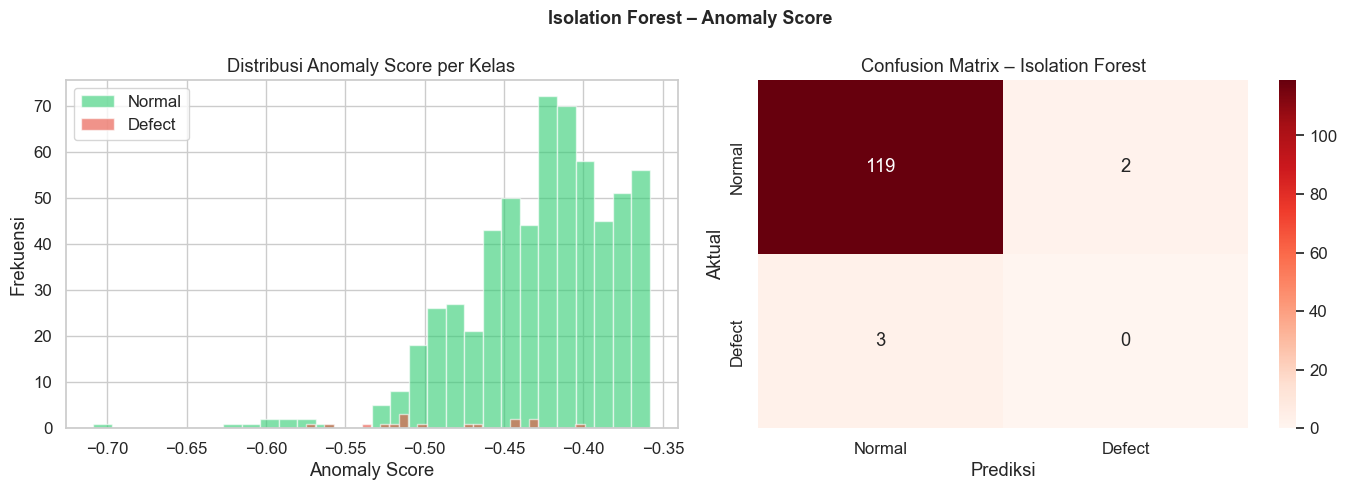

In [6]:
# Visualisasi distribusi anomaly score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Isolation Forest – Anomaly Score", fontsize=13, fontweight='bold')

# Histogram
for kelas, color, label in [(0, COLORS['normal'], 'Normal'), (1, COLORS['defect'], 'Defect')]:
    mask = df_model[TARGET] == kelas
    axes[0].hist(df_model.loc[mask, 'IF_Anomaly_Score'], bins=30,
                 color=color, alpha=0.6, label=label, edgecolor='white')
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Anomaly Score per Kelas")
axes[0].legend()

# Confusion matrix IF
cm_if = confusion_matrix(y_test, y_pred_if_test)
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal','Defect'], yticklabels=['Normal','Defect'], ax=axes[1])
axes[1].set_title("Confusion Matrix – Isolation Forest")
axes[1].set_xlabel("Prediksi"); axes[1].set_ylabel("Aktual")

plt.tight_layout()
plt.show()

## 🌳 6. Random Forest – Klasifikasi

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',   # atasi imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)

y_pred_rf   = rf.predict(X_test_sc)
y_proba_rf  = rf.predict_proba(X_test_sc)[:, 1]

print("📊 Random Forest – Test Set Results:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Defect']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"Avg Precision : {average_precision_score(y_test, y_proba_rf):.4f}")

📊 Random Forest – Test Set Results:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       121
      Defect       1.00      0.67      0.80         3

    accuracy                           0.99       124
   macro avg       1.00      0.83      0.90       124
weighted avg       0.99      0.99      0.99       124

ROC-AUC Score : 1.0000
Avg Precision : 1.0000


In [8]:
# ── Cross-Validation (StratifiedKFold k=5) ──────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1  = cross_val_score(rf, X_all_sc, y, cv=skf, scoring='f1', n_jobs=-1)
cv_auc = cross_val_score(rf, X_all_sc, y, cv=skf, scoring='roc_auc', n_jobs=-1)

print("\n📈 5-Fold Cross-Validation:")
print(f"  F1 Score  : {cv_f1.mean():.4f}  (±{cv_f1.std():.4f})")
print(f"  ROC-AUC   : {cv_auc.mean():.4f}  (±{cv_auc.std():.4f})")
print(f"  F1  per fold : {[f'{v:.3f}' for v in cv_f1]}")
print(f"  AUC per fold : {[f'{v:.3f}' for v in cv_auc]}")


📈 5-Fold Cross-Validation:
  F1 Score  : 0.9200  (±0.0980)
  ROC-AUC   : 1.0000  (±0.0000)
  F1  per fold : ['0.800', '1.000', '1.000', '0.800', '1.000']
  AUC per fold : ['1.000', '1.000', '1.000', '1.000', '1.000']


## 🔧 7. Hyperparameter Tuning (RandomizedSearchCV)

In [9]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators'   : [100, 200, 300, 500],
    'max_depth'      : [5, 8, 10, 15, None],
    'min_samples_leaf': [2, 5, 10],
    'max_features'   : ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_search.fit(X_train_sc, y_train)

print(f"✅ Best params : {rf_search.best_params_}")
print(f"   Best F1 CV  : {rf_search.best_score_:.4f}")

rf_best = rf_search.best_estimator_
y_pred_best  = rf_best.predict(X_test_sc)
y_proba_best = rf_best.predict_proba(X_test_sc)[:, 1]

print("\n📊 Best Model – Test Set Results:")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Defect']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

✅ Best params : {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 5}
   Best F1 CV  : 0.8933

📊 Best Model – Test Set Results:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       121
      Defect       1.00      0.67      0.80         3

    accuracy                           0.99       124
   macro avg       1.00      0.83      0.90       124
weighted avg       0.99      0.99      0.99       124

ROC-AUC: 1.0000


## 📊 8. Evaluasi & Visualisasi Lengkap

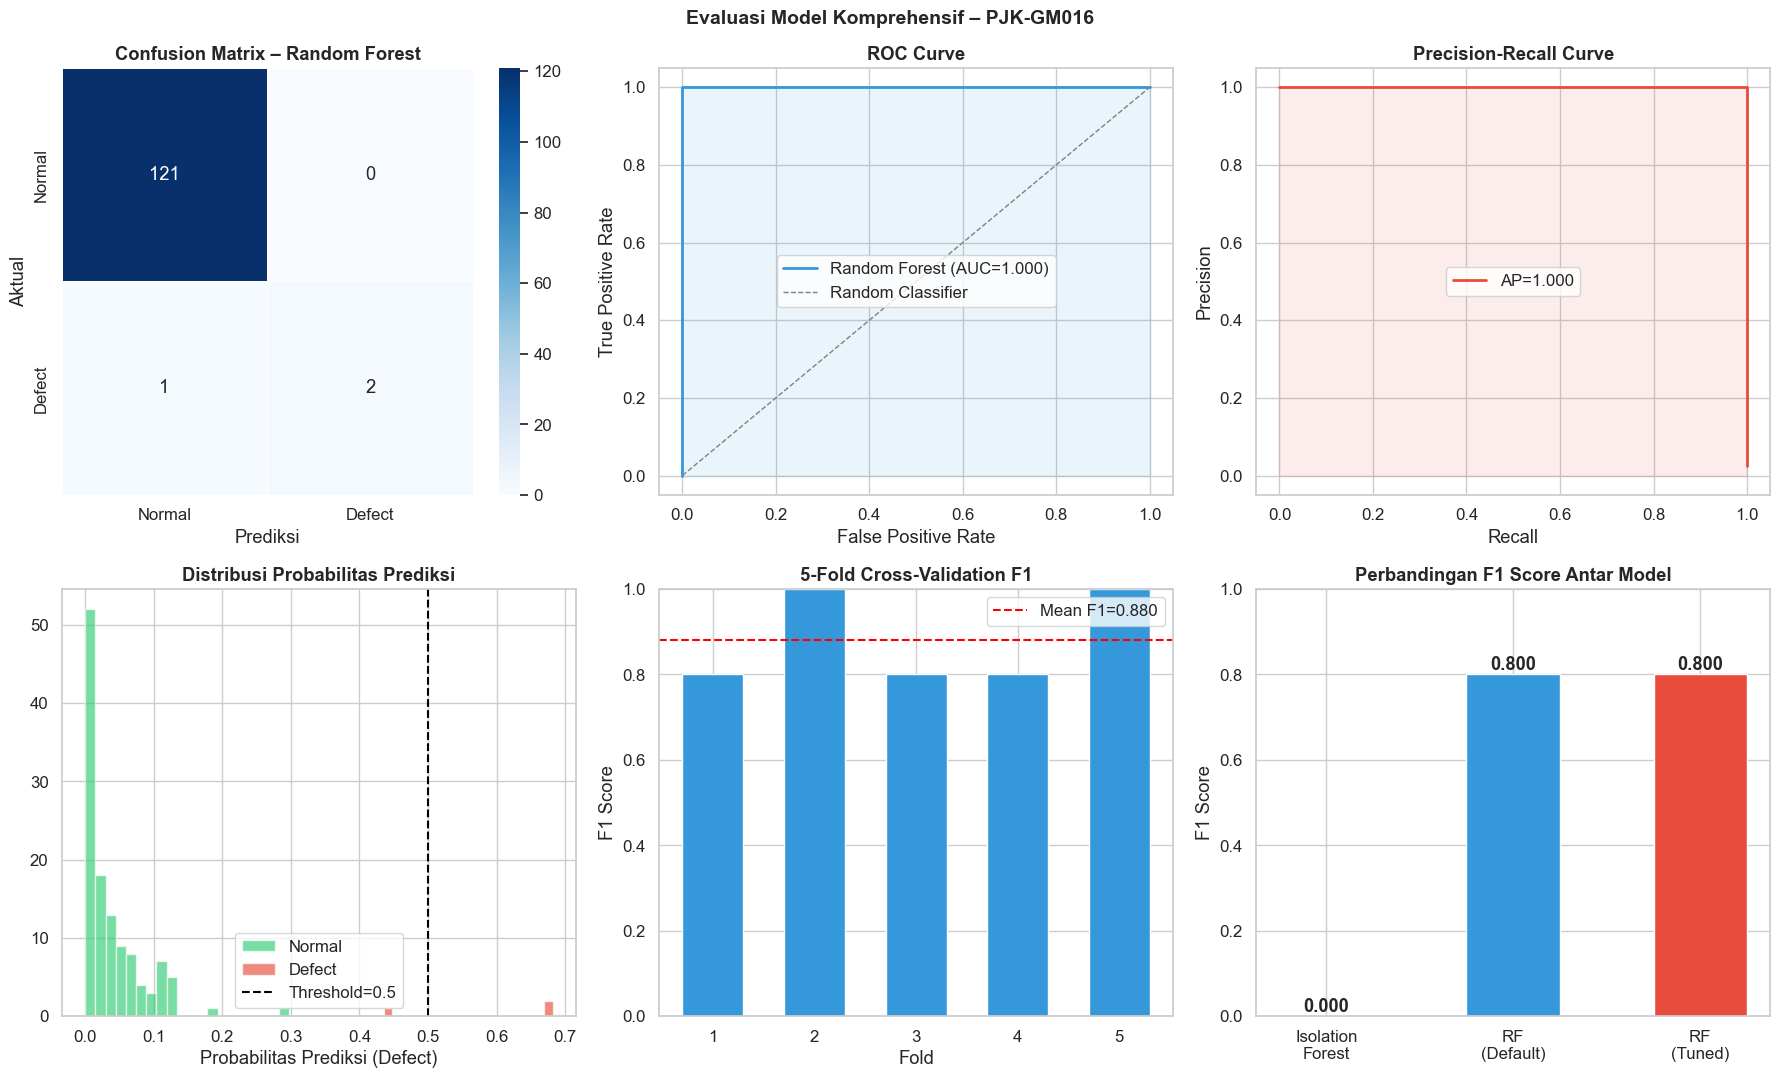


✅ Grafik evaluasi tersimpan: model_evaluation.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Evaluasi Model Komprehensif – PJK-GM016", fontsize=14, fontweight='bold')

# ── A. Confusion Matrix RF ────────────────────────────────────────
cm_rf = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Defect'], yticklabels=['Normal','Defect'],
            ax=axes[0,0], linewidths=0.5)
axes[0,0].set_title("Confusion Matrix – Random Forest", fontweight='bold')
axes[0,0].set_xlabel("Prediksi"); axes[0,0].set_ylabel("Aktual")

# ── B. ROC Curve ────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_val      = roc_auc_score(y_test, y_proba_best)
axes[0,1].plot(fpr, tpr, color='#3498db', lw=2, label=f'Random Forest (AUC={auc_val:.3f})')
axes[0,1].plot([0,1],[0,1],'--', color='gray', lw=1, label='Random Classifier')
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[0,1].set_xlabel("False Positive Rate"); axes[0,1].set_ylabel("True Positive Rate")
axes[0,1].set_title("ROC Curve", fontweight='bold'); axes[0,1].legend()

# ── C. Precision-Recall Curve ────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_test, y_proba_best)
ap_val        = average_precision_score(y_test, y_proba_best)
axes[0,2].plot(rec, prec, color='#e74c3c', lw=2, label=f'AP={ap_val:.3f}')
axes[0,2].fill_between(rec, prec, alpha=0.1, color='#e74c3c')
axes[0,2].set_xlabel("Recall"); axes[0,2].set_ylabel("Precision")
axes[0,2].set_title("Precision-Recall Curve", fontweight='bold'); axes[0,2].legend()

# ── D. Distribusi Probabilitas Prediksi ─────────────────────────
for kelas, color, label in [(0, COLORS['normal'], 'Normal'), (1, COLORS['defect'], 'Defect')]:
    mask = y_test == kelas
    axes[1,0].hist(y_proba_best[mask], bins=20, color=color,
                   alpha=0.65, label=label, edgecolor='white')
axes[1,0].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
axes[1,0].set_xlabel("Probabilitas Prediksi (Defect)")
axes[1,0].set_title("Distribusi Probabilitas Prediksi", fontweight='bold')
axes[1,0].legend()

# ── E. CV Score Distribution ─────────────────────────────────────
cv_scores = cross_val_score(rf_best, X_all_sc, y, cv=skf, scoring='f1', n_jobs=-1)
axes[1,1].bar(range(1, 6), cv_scores, color='#3498db', edgecolor='white', width=0.6)
axes[1,1].axhline(cv_scores.mean(), color='red', linestyle='--', lw=1.5,
                   label=f'Mean F1={cv_scores.mean():.3f}')
axes[1,1].set_xlabel("Fold"); axes[1,1].set_ylabel("F1 Score")
axes[1,1].set_title("5-Fold Cross-Validation F1", fontweight='bold')
axes[1,1].legend(); axes[1,1].set_ylim([0, 1])

# ── F. Perbandingan Model ────────────────────────────────────────
models_name = ['Isolation\nForest', 'RF\n(Default)', 'RF\n(Tuned)']
f1_scores   = [
    f1_score(y_test, y_pred_if_test),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_best)
]
bar_colors = ['#95a5a6', '#3498db', '#e74c3c']
bars = axes[1,2].bar(models_name, f1_scores, color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, f1_scores):
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{val:.3f}', ha='center', fontweight='bold')
axes[1,2].set_ylabel("F1 Score"); axes[1,2].set_ylim([0, 1])
axes[1,2].set_title("Perbandingan F1 Score Antar Model", fontweight='bold')

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Grafik evaluasi tersimpan: model_evaluation.png")

## 📌 9. Feature Importance

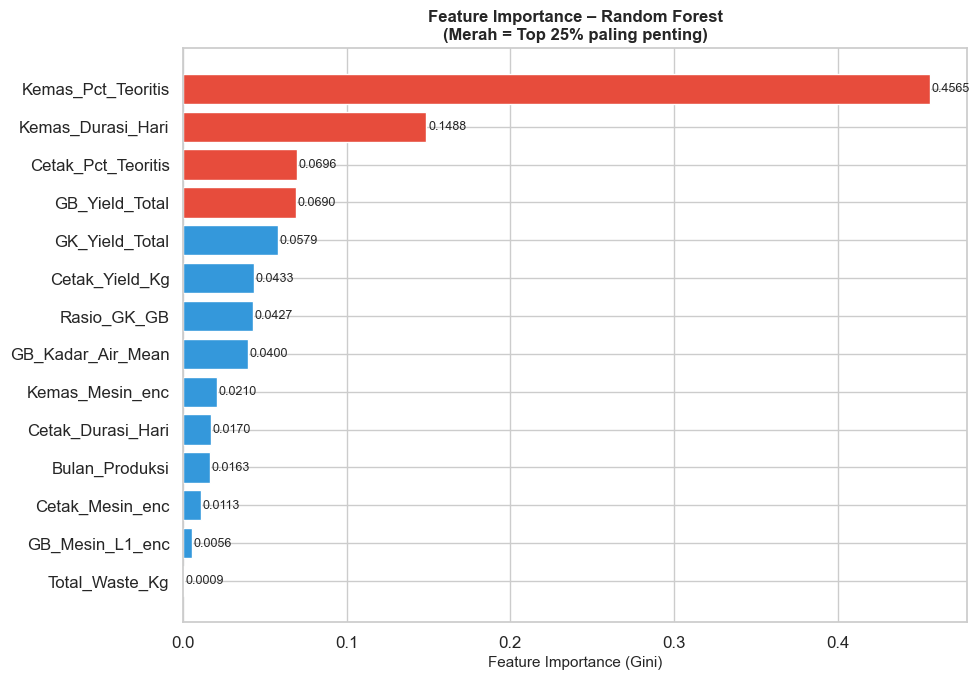


🏆 Top 5 Fitur Paling Penting:
Kemas_Pct_Teoritis    0.456479
Kemas_Durasi_Hari     0.148793
Cetak_Pct_Teoritis    0.069592
GB_Yield_Total        0.069033
GK_Yield_Total        0.057906


In [11]:
importances = pd.Series(rf_best.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = ['#e74c3c' if v > importances.quantile(0.75) else '#3498db'
             for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors_fi, edgecolor='white')
ax.set_xlabel("Feature Importance (Gini)", fontsize=11)
ax.set_title("Feature Importance – Random Forest\n(Merah = Top 25% paling penting)",
             fontweight='bold', fontsize=12)

for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n🏆 Top 5 Fitur Paling Penting:")
print(importances.sort_values(ascending=False).head(5).to_string())

In [12]:
# Tambahkan prediksi ke dataframe asli
df['RF_Pred']     = rf_best.predict(scaler.transform(
    df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())))
df['RF_Proba']    = rf_best.predict_proba(scaler.transform(
    df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())))[:, 1]
df['IF_Pred_All'] = (iso_forest.predict(scaler.transform(
    df[FEATURE_COLS].fillna(df[FEATURE_COLS].median()))) == -1).astype(int)

df.to_csv("rekap_produksi_with_predictions.csv", index=False)
print("✅ CSV dengan prediksi tersimpan: rekap_produksi_with_predictions.csv")

✅ CSV dengan prediksi tersimpan: rekap_produksi_with_predictions.csv


## 💾 10. Simpan Model

In [13]:
joblib.dump(rf_best,    'models/random_forest_model.pkl')
joblib.dump(iso_forest, 'models/isolation_forest_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')

with open('models/feature_cols.txt', 'w') as f:
    f.write('\n'.join(FEATURE_COLS))

print("✅ Model tersimpan di folder models/:")
print("   models/random_forest_model.pkl")
print("   models/isolation_forest_model.pkl")
print("   models/scaler.pkl")
print("   models/feature_cols.txt")

# Ringkasan final
print("\n" + "="*55)
print("  RINGKASAN HASIL MODELING – PJK-GM016")
print("="*55)
print(f"  Best Model      : Random Forest (Tuned)")
print(f"  Best Params     : {rf_search.best_params_}")
print(f"  F1 Score (test) : {f1_score(y_test, y_pred_best):.4f}")
print(f"  ROC-AUC (test)  : {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"  CV F1 Mean      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("="*55)
print("\n✅ Selesai! Lanjut ke 04_clustering.ipynb")

✅ Model tersimpan di folder models/:
   models/random_forest_model.pkl
   models/isolation_forest_model.pkl
   models/scaler.pkl
   models/feature_cols.txt

  RINGKASAN HASIL MODELING – PJK-GM016
  Best Model      : Random Forest (Tuned)
  Best Params     : {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 5}
  F1 Score (test) : 0.8000
  ROC-AUC (test)  : 1.0000
  CV F1 Mean      : 0.8800 ± 0.0980

✅ Selesai! Lanjut ke 04_clustering.ipynb
